# Softmax Regression using TensorFlow

## Softmax Regression Simplified
Softmax regression (or multinomial logistic regression) is an extension of logistic regression used for multi-class classification. Instead of just two labels {0,1}, it can classify data into three or more categories.

## Why Softmax?
When classifying digits {0,1,2,...,9}, we need a way to convert raw scores into probabilities. The Softmax function does this by:

Converting scores into probabilities (so each class gets a probability).
Ensuring probabilities sum to 1, making it a valid probability distribution.
## Loss Function: Cross-Entropy
To train the model, we compare the predicted probabilities with the actual labels (which are one-hot encoded). The Cross-Entropy loss measures how far our predicted probabilities are from the correct labels.

Correct predictions → Lower loss

Wrong predictions → Higher loss

By minimizing this loss using Gradient Descent, the model improves its predictions.

# Implementation of Softmax Regression using TensorFlow for a multi-class classification problem (MNIST digit classification).

# 1. Import Required Libraries

In [7]:
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow import keras  # Keras for high-level API
import numpy as np  # NumPy for numerical operations
import matplotlib.pyplot as plt  # Matplotlib for data visualization
from tensorflow.keras.utils import to_categorical  # One-hot encoding

# 2. Load and Preprocess the Dataset

We will use the MNIST dataset, which consists of 28x28 grayscale images of digits from 0 to 9.

In [10]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Print dataset shapes
print(f"Training set: {X_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {X_test.shape}, Labels: {y_test.shape}")

Training set: (60000, 28, 28), Labels: (60000,)
Testing set: (10000, 28, 28), Labels: (10000,)


# Normalize the Images
To improve model performance, we normalize pixel values from [0,255] to [0,1].

In [14]:
X_train, X_test = X_train / 255.0, X_test / 255.0

# Flatten the Images
The MNIST dataset contains 28×28 pixel images.
Since softmax regression only works with 1D feature vectors, we flatten each image into a 1D vector of 784 values.

In [17]:
X_train = X_train.reshape(-1, 28 * 28)  # Shape: (60000, 784)
X_test = X_test.reshape(-1, 28 * 28)    # Shape: (10000, 784)

# Convert Labels to One-Hot Encoding
Softmax regression requires labels in one-hot encoded format.
For example:

Digit 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

Digit 7 → [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

In [22]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print a sample one-hot encoded label
print("Sample one-hot label:", y_train[0])

Sample one-hot label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# 3. Build the Softmax Regression Model
Softmax regression consists of:

An input layer with 784 neurons (one for each pixel).

A single Dense (fully connected) layer with 10 output neurons (one for each digit).

A softmax activation function, which converts scores into probabilities.



In [26]:
# Define the model
model = keras.Sequential([
    keras.layers.Dense(10, activation='softmax', input_shape=(784,))
])

# Print model summary
model.summary()

C:\Users\franc\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │           7,850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

# 4. Compile and Train the Model
Compile the Model

We use:

Adam optimizer for adaptive learning.

Categorical Cross-Entropy as the loss function for multi-class classification.

Accuracy as the metric to evaluate performance.

In [29]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# Train the Model
We train the model for 10 epochs using a batch size of 32.

We also use 10% of training data as validation data.

In [32]:
history = model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8098 - loss: 0.7492 - val_accuracy: 0.9267 - val_loss: 0.2732
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9095 - loss: 0.3254 - val_accuracy: 0.9320 - val_loss: 0.2461
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9186 - loss: 0.2937 - val_accuracy: 0.9352 - val_loss: 0.2370
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9202 - loss: 0.2857 - val_accuracy: 0.9387 - val_loss: 0.2297
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9249 - loss: 0.2730 - val_accuracy: 0.9387 - val_loss: 0.2267
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9265 - loss: 0.2647 - val_accuracy: 0.9360 - val_loss: 0.2295
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9253 - loss: 0.2662 - val_accuracy: 0.9392 - val_loss: 0.2227
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9271 - loss: 0.2602 -

# 5. Evaluate Model Performance
After training, we evaluate the model on the test set.

In [35]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9151 - loss: 0.3025
Test Accuracy: 0.9262


# 6. Make Predictions
Let's use the trained model to predict some images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


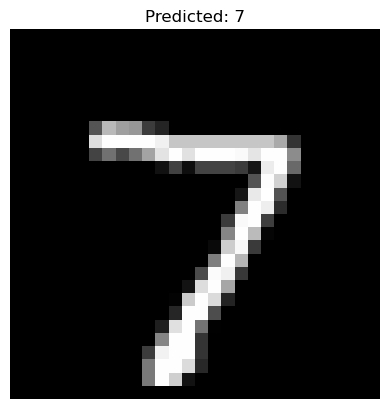

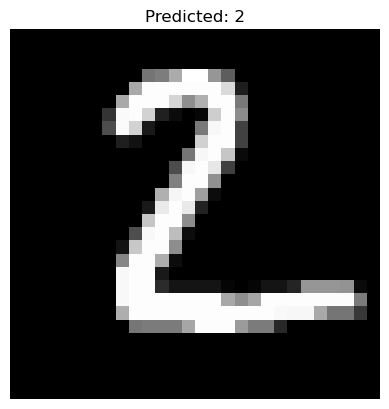

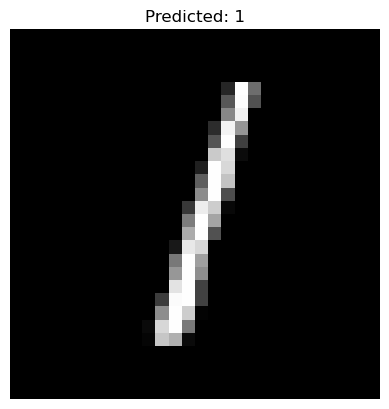

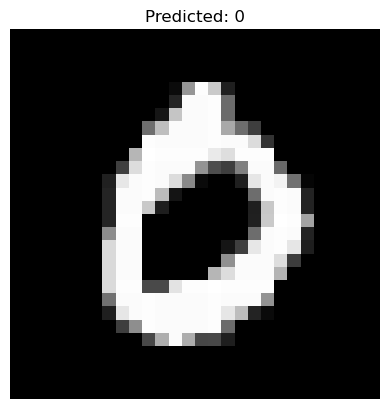

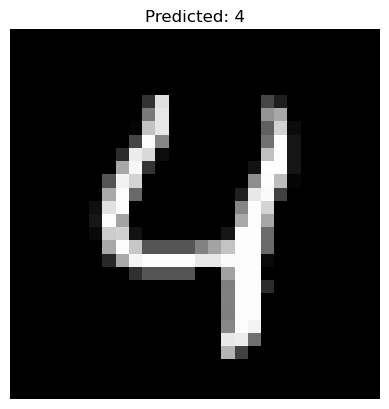

In [38]:
# Get predictions for first 5 test images
predictions = model.predict(X_test[:5])

# Display the first 5 test images with predicted labels
for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])}")
    plt.axis('off')
    plt.show()